不同N M占比 peak关于beta的函数

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(2025)

# ---------------------------
# 1. 核心模型函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N = len(n); M = R.shape[1]
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        flows = n * g_i * R[:, j]
        num = np.sum(flows * p_A_res)
        den = np.sum(flows)
        tilde_p_A[j] = num / den if den > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    M_U = np.zeros(M); M_A = np.zeros(M)
    p_I = states[:, 2]
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for k in range(N):
            flow = n[k] * g_i[k] * R[k, j]
            prod_U *= np.power(1 - beta_U * p_I[k], flow)
            prod_A *= np.power(1 - beta_A * p_I[k], flow)
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    N = len(n)
    Q_U = np.zeros(N); Q_A = np.zeros(N)
    for i in range(N):
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * np.sum(R[i] * M_U)
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * np.sum(R[i] * M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = [states[:, i] for i in range(5)]
    new = np.zeros_like(states)
    new[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r
    new /= np.clip(new.sum(axis=1, keepdims=True), 1e-10, None)
    return new

def update_population(n, states, g_i, epsilon, R, T):
    N, M = R.shape
    X = states * n[:, None]
    F = n * g_i * epsilon
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 中转站流入
    m = np.zeros(M); m_X = np.zeros((M, 5))
    for j in range(M):
        flows = n * g_i * epsilon * R[:, j]
        m[j] = flows.sum()
        m_X[j] = (X * (g_i * epsilon)[:, None] * R[:, j][:, None]).sum(axis=0)

    # 返回
    flow_return = np.zeros(N); flow_return_X = np.zeros((N, 5))
    for j in range(M):
        flow_return += m[j] * T[:, j]
        flow_return_X += np.outer(T[:, j], m_X[j])

    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states

def main_simulation(Time, N, M, params):
    lambda1, mu1, mu2 = params['lambda1'], params['mu1'], params['mu2']
    beta_U, beta_A = params['beta_U'], params['beta_A']
    g_i = np.full(N, params['theta'] * params['g'])
    n = np.arange(30, 30 + 60 * N, 60, dtype=int)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99; states[:, 2] = 0.01
    states /= states.sum(axis=1, keepdims=True)

    # 随机网络
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)
    T = w / w.sum(axis=0, keepdims=True)

    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))

    for t in range(Time):
        state_history[t], pop_history[t] = states, n.copy()
        epsilon = compute_epsilon(states, params['alpha'], params['epsilon0'])
        n, states = update_population(n, states, g_i, epsilon, R, T)
        tilde_p_A = compute_effective_awareness(n, states, g_i, R)
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        N_U, N_A = compute_infection_residence(n, states, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n, states, g_i, R, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A)
        states = update_states(states, r, Q_U, Q_A, mu1, mu2)

    return state_history, pop_history




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Experiment settings
Time = 140
epsilon0 = 0.3
beta_values = np.linspace(0.0, 0.0305, 121)  # finer grid
num_sims = 100

# Parameter combinations for (N, M)
combinations = [
    (10, 20),
    (12, 18),
    (15, 15),
    (18, 12),
    (20, 10),
]

# Base params
base_params = {
    'lambda1': 0.5,  
    'mu1': 0.15,
    'mu2': 0.2,
    'beta_U': None, # to be set
    'beta_A': None,
    'g': 0.5,
    'epsilon0': epsilon0,
    'alpha': 0.3,
    'theta': 1
}

# Storage
mean_peaks = {comb: [] for comb in combinations}

# Run experiments
for comb in combinations:
    N, M = comb
    for beta_U in tqdm(beta_values, desc=f"Running λ sweep for N={N}, M={M}"):
        base_params['beta_U'] = beta_U
        base_params['beta_A'] = beta_U * 0.5
        # collect peaks over sims
        peaks = []
        for _ in range(num_sims):
            history, pop_hist = main_simulation(Time, N, M, base_params)
            # compute global AI peak
            ai_t = [
                np.sum(history[t] * pop_hist[t][:, None], axis=0)[2] / np.sum(pop_hist[t])
                for t in range(Time)
            ]
            peaks.append(max(ai_t))
        mean_peaks[comb].append(np.mean(peaks))



Running λ sweep for N=20, M=10: 100%|██████████| 121/121 [47:58<00:00, 23.79s/it]


In [56]:
import numpy as np
import pandas as pd

print(mean_peaks)
print(mean_peaks.keys()) # 查询字典键值 dict_keys([(10, 20), (12, 18), (15, 15), (18, 12), (20, 10)])
print(mean_peaks[(10,20)]) # 查询字典值 按key [0.010000000000000005, 0.010000000000000005, 0.010000000000000005]

col_names = [f'N={n}, M={m}' for (n, m) in mean_peaks.keys()]
print(col_names) # ['N=10,M=20', 'N=12,M=18', 'N=15,M=15', 'N=18,M=12', 'N=20,M=10']


'''
zip(col_names, mean_peaks.keys())
[
  ("N=10,M=20", (10,20)),
  ("N=15,M=15", (15,15)),
  ("N=20,M=10", (20,10)),
]
'''

df = pd.DataFrame(
    data = {
    col: mean_peaks[comb]
    for col, comb in zip(col_names, mean_peaks.keys())
    },
    index=beta_values
)
df.index.name = 'beta'
print("----------------")
print(df)
df.to_csv('peakAI_by_NM_beta.csv')

{(10, 20): [0.010000000000000004, 0.010000000000000004, 0.010000000000000004, 0.010000000000000004, 0.010000000000000004, 0.010000000000000004, 0.01075830749890479, 0.015059095586746972, 0.020823470247191098, 0.029445247937135047, 0.03923975974394699, 0.052990478663795866, 0.06864251269654963, 0.08561126139833261, 0.10602778570948818, 0.12572373802193018, 0.1452009447058508, 0.16511814868164457, 0.1852402021516726, 0.2037361173751114, 0.22057181224892342, 0.23839035680687468, 0.2551189135736298, 0.27156865324263846, 0.2857767705450371, 0.3006854585095825, 0.31433528522767523, 0.32768660131486976, 0.3409161896243081, 0.3515900585891656, 0.3648274007032198, 0.3767907731753404, 0.38780879872883645, 0.39614524508237037, 0.4049811500953579, 0.41553449221433575, 0.42624764168731366, 0.4358157058058382, 0.4430542187394992, 0.45124075272026465, 0.4571718683910011, 0.46301986810581214, 0.472281104096873, 0.4805030433426562, 0.4883800740441972, 0.49564562462832845, 0.5019901838871991, 0.50825263

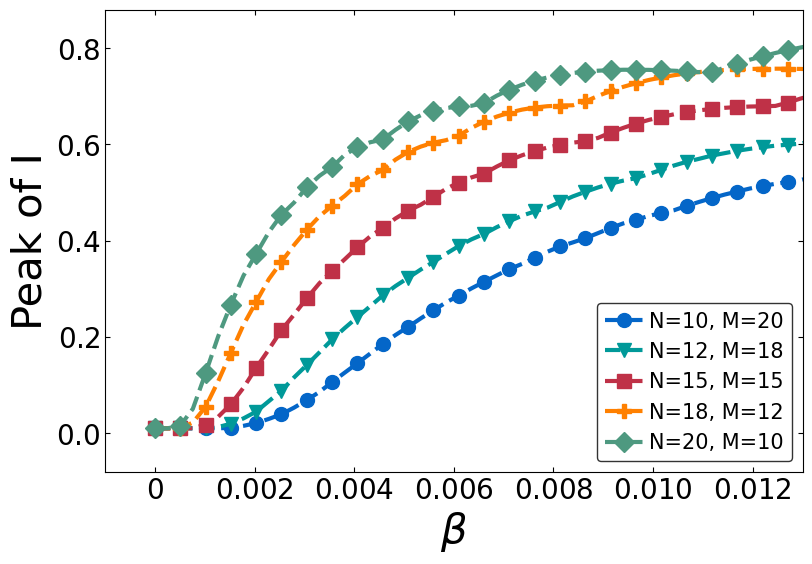

In [53]:
# Plotting
plt.figure(figsize=(9, 6))
styles = [
    {'label': 'N=10, M=20', 'color': '#0466c8', 'marker': 'o'},
    {'label': 'N=12, M=18', 'color': '#009999', 'marker': 'v'},
    {'label': 'N=15, M=15', 'color': '#BF3147', 'marker': 's'},
    {'label': 'N=18, M=12', 'color': '#FF8000', 'marker': 'P'},
    {'label': 'N=20, M=10', 'color': '#4E9980', 'marker': 'D'},
]

for (comb, style) in zip(combinations, styles):
    plt.plot(beta_values,
             mean_peaks[comb],
             label=style['label'],
             color=style['color'],
             marker=style['marker'],
             markevery=2,
             linewidth=3,
             linestyle='--',
             markersize=10)

legend = plt.legend(
    loc='lower right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    borderpad=0.4,          # 图例内边距
    handlelength=1.8,    # 统一图标宽度
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
    
# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


plt.xlabel(r'$\beta$', fontsize=30)
# plt.xticks([0.000, 0.005, 0.010, 0.015, 0.020, 0.025, 0.030],[r'$0$', r'$0.005$', r'$0.010$', r'$0.015$', r'$0.020$', r'$0.025$', r'$0.030$'], fontsize=20)
# plt.xlim(-0.001, 0.031)
plt.xticks([0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.012],[ r'$0$', r'$0.002$', r'$0.004$', r'$0.006$', r'$0.008$', r'$0.010$', r'$0.012$' ],fontsize=20)
plt.xlim(-0.001, 0.013)


plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8],[r'$0.0$', r'$0.2$', r'$0.4$', r'$0.6$', r'$0.8$'],fontsize=20)
plt.ylim(-0.08, 0.88)

plt.show()